# Sokoban A* Heuristic Optimization — Visualization

Slide-ready charts for the LLM-driven heuristic optimization pipeline.  
Loads results from `optimization_results.json` produced by `heuristic_optimizer.py`.

In [64]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Style settings (tweak these for your slides) ─────────────────
FONT_SIZE    = 13
TITLE_SIZE   = 16
FIG_W, FIG_H = 14, 5        # default figure width / height
BAR_WIDTH    = 0.22          # width of each bar in grouped charts
DPI          = 150           # export resolution
SAVE_FIGS    = False         # set True to auto-save PNGs

COLORS = {
    'naive_manhattan': '#d29922',
    'greedy_matching': '#bc8cff',
    'enhanced':        '#58a6ff',
    'llm_best':        '#3fb950',
    'accepted':        '#3fb950',
    'rejected':        '#f85149',
    'baseline':        '#58a6ff',
}

plt.rcParams.update({
    'font.size': FONT_SIZE,
    'axes.titlesize': TITLE_SIZE,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'savefig.dpi': DPI,
    'savefig.bbox': 'tight',
})

def save(fig, name):
    if SAVE_FIGS:
        fig.savefig(f'figures/{name}.png')
        print(f'Saved figures/{name}.png')

In [65]:
# ── Load data ─────────────────────────────────────────────────────
with open('optimization_results_50_select_20.json') as f:
    data = json.load(f)

levels     = data['levels']
baselines  = data['baselines']
iterations = data['iterations']
best_info  = data['best']

# Convenience: per-level node arrays for each baseline
naive_nodes    = [r['nodes'] for r in baselines['naive_manhattan']['results']]
greedy_nodes   = [r['nodes'] for r in baselines['greedy_matching']['results']]
enhanced_nodes = [r['nodes'] for r in baselines['enhanced']['results']]

# Best LLM iteration
best_iter = [it for it in iterations if it['accepted']][-1]
llm_nodes = [r['nodes'] for r in best_iter['results']]

print(f'Levels: {len(levels)}')
print(f'Iterations: {len(iterations)} ({sum(1 for it in iterations if it["accepted"])} accepted)')
print(f'Naive total:    {sum(naive_nodes):>8,}')
print(f'Greedy total:   {sum(greedy_nodes):>8,}')
print(f'Enhanced total: {sum(enhanced_nodes):>8,}')
print(f'LLM Best total: {sum(llm_nodes):>8,}')

Levels: 50
Iterations: 10 (5 accepted)
Naive total:     411,392
Greedy total:    371,898
Enhanced total:  295,643
LLM Best total:  104,221


## 1. Optimization Timeline

Total nodes explored per iteration — accepted vs rejected.

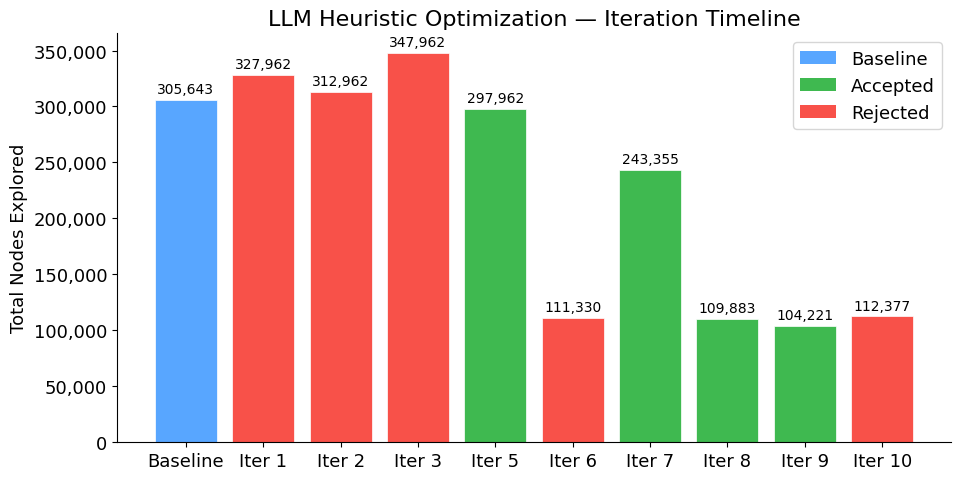

In [66]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.7, FIG_H))

iter_labels = []
iter_nodes  = []
iter_colors = []

for it in iterations:
    label = 'Baseline' if it['iteration'] == 0 else f"Iter {it['iteration']}"
    iter_labels.append(label)
    total = sum(r['nodes'] for r in it['results'])
    iter_nodes.append(total)
    if it['iteration'] == 0:
        iter_colors.append(COLORS['baseline'])
    elif it['accepted']:
        iter_colors.append(COLORS['accepted'])
    else:
        iter_colors.append(COLORS['rejected'])

bars = ax.bar(iter_labels, iter_nodes, color=iter_colors, edgecolor='white', linewidth=0.5)

# Value labels on top
for bar, val in zip(bars, iter_nodes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(iter_nodes)*0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10)

ax.set_ylabel('Total Nodes Explored')
ax.set_title('LLM Heuristic Optimization — Iteration Timeline')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor=COLORS['baseline'], label='Baseline'),
    Patch(facecolor=COLORS['accepted'], label='Accepted'),
    Patch(facecolor=COLORS['rejected'], label='Rejected'),
]
ax.legend(handles=legend_elems, loc='upper right')

plt.tight_layout()
save(fig, 'timeline')
plt.show()

## 2. Per-Level Node Comparison (Grouped Bar)

Compare all heuristics side by side for each level.

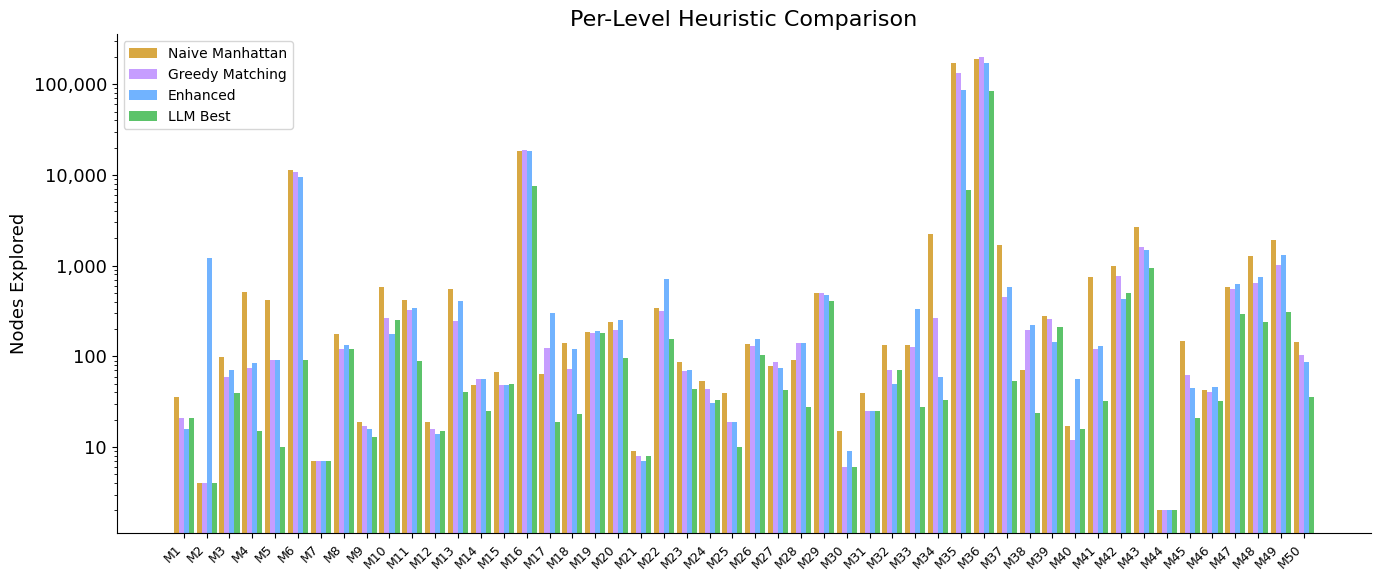

In [67]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

x = np.arange(len(levels))
w = BAR_WIDTH

ax.bar(x - 1.5*w, naive_nodes,    w, label='Naive Manhattan', color=COLORS['naive_manhattan'], alpha=0.85)
ax.bar(x - 0.5*w, greedy_nodes,   w, label='Greedy Matching', color=COLORS['greedy_matching'], alpha=0.85)
ax.bar(x + 0.5*w, enhanced_nodes, w, label='Enhanced',        color=COLORS['enhanced'],        alpha=0.85)
ax.bar(x + 1.5*w, llm_nodes,      w, label='LLM Best',        color=COLORS['llm_best'],        alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('Microban ', 'M') for l in levels],
                    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Nodes Explored')
ax.set_title('Per-Level Heuristic Comparison')
ax.set_yscale('log')
ax.legend(loc='upper left', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save(fig, 'per_level_comparison')
plt.show()

## 3. Improvement Heatmap

Shows percentage improvement of LLM Best vs Enhanced baseline per level.

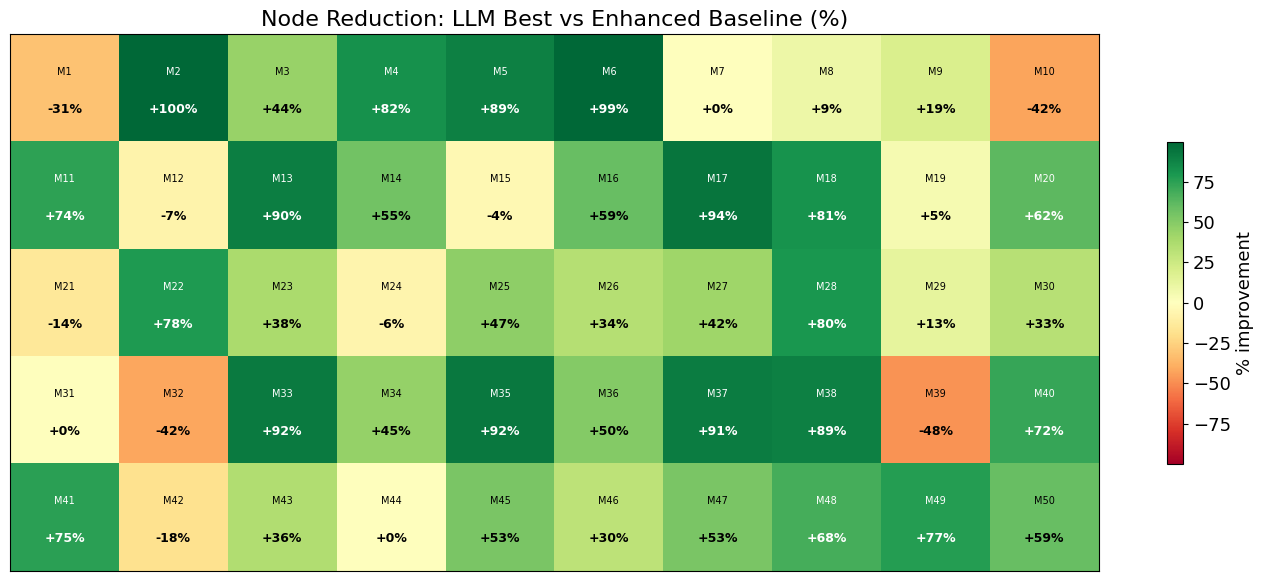

In [68]:
improvements = []
for e, l in zip(enhanced_nodes, llm_nodes):
    imp = (e - l) / e * 100 if e > 0 else 0
    improvements.append(imp)

# Reshape for heatmap (single row or multi-row)
n = len(levels)
cols = min(n, 10)
rows = (n + cols - 1) // cols
padded = improvements + [0] * (rows * cols - n)
heat = np.array(padded).reshape(rows, cols)
labels_grid = levels + [''] * (rows * cols - n)
labels_2d = np.array(labels_grid).reshape(rows, cols)

fig, ax = plt.subplots(figsize=(FIG_W, max(2, rows * 1.2)))

cmap = plt.cm.RdYlGn  # red=worse, green=better
vmax = max(abs(min(improvements)), abs(max(improvements)), 1)
im = ax.imshow(heat, cmap=cmap, aspect='auto', vmin=-vmax, vmax=vmax)

# Annotations
for i in range(rows):
    for j in range(cols):
        idx = i * cols + j
        if idx >= n:
            continue
        val = improvements[idx]
        short = levels[idx].replace('Microban ', 'M')
        color = 'white' if abs(val) > vmax * 0.6 else 'black'
        ax.text(j, i - 0.15, short, ha='center', va='center', fontsize=7, color=color)
        ax.text(j, i + 0.2, f'{val:+.0f}%', ha='center', va='center',
                fontsize=9, fontweight='bold', color=color)

ax.set_xticks([])
ax.set_yticks([])
ax.set_title('Node Reduction: LLM Best vs Enhanced Baseline (%)')
plt.colorbar(im, ax=ax, label='% improvement', shrink=0.6)

plt.tight_layout()
save(fig, 'improvement_heatmap')
plt.show()

## 4. Summary Table

Total nodes for each heuristic with improvement percentages.

In [69]:
import pandas as pd

rows_data = []
for i, name in enumerate(levels):
    e = enhanced_nodes[i]
    l = llm_nodes[i]
    imp = (e - l) / e * 100 if e > 0 else 0
    rows_data.append({
        'Level': name,
        'Naive Manhattan': naive_nodes[i],
        'Greedy Matching': greedy_nodes[i],
        'Enhanced': e,
        'LLM Best': l,
        'Improvement (%)': round(imp, 1),
    })

df = pd.DataFrame(rows_data)

# Add totals row
totals = {
    'Level': 'TOTAL',
    'Naive Manhattan': sum(naive_nodes),
    'Greedy Matching': sum(greedy_nodes),
    'Enhanced': sum(enhanced_nodes),
    'LLM Best': sum(llm_nodes),
    'Improvement (%)': round((sum(enhanced_nodes) - sum(llm_nodes)) / sum(enhanced_nodes) * 100, 1),
}
df = pd.concat([df, pd.DataFrame([totals])], ignore_index=True)

# Style: highlight improvement column
def color_improvement(val):
    if isinstance(val, (int, float)):
        if val > 0:
            return 'color: green; font-weight: bold'
        elif val < 0:
            return 'color: red; font-weight: bold'
    return ''

styled = df.style.map(color_improvement, subset=['Improvement (%)'])
styled = styled.format({
    'Naive Manhattan': '{:,}',
    'Greedy Matching': '{:,}',
    'Enhanced': '{:,}',
    'LLM Best': '{:,}',
    'Improvement (%)': '{:+.1f}%',
})
styled

,Level,Naive Manhattan,Greedy Matching,Enhanced,LLM Best,Improvement (%)
0,Microban 1,36,21,16,21,-31.2%
1,Microban 2,4,4,"1,223",4,+99.7%
2,Microban 3,98,59,70,39,+44.3%
3,Microban 4,518,74,84,15,+82.1%
4,Microban 5,422,91,91,10,+89.0%
5,Microban 6,"11,257","10,686","9,561",92,+99.0%
6,Microban 7,7,7,7,7,+0.0%
7,Microban 8,177,122,134,122,+9.0%
8,Microban 9,19,17,16,13,+18.8%
9,Microban 10,586,263,178,253,-42.1%


## 5. Radar Chart — Heuristic Profile

Normalized performance across a subset of representative levels.

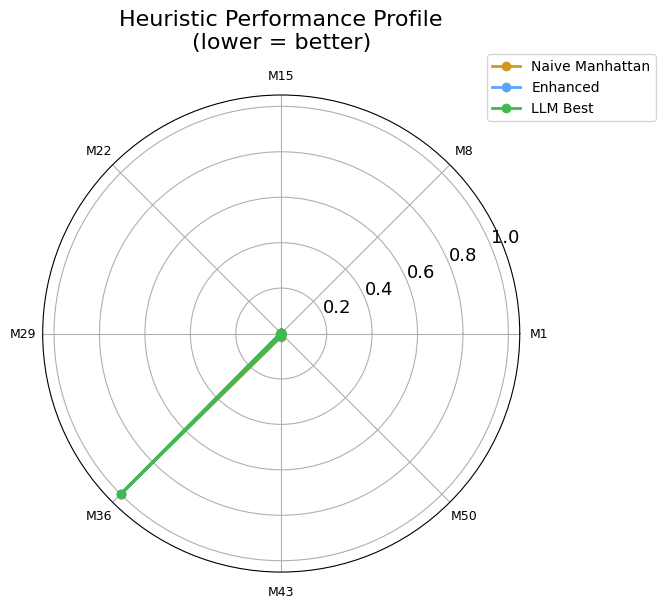

In [70]:
# Pick representative levels (spread across difficulty)
n_levels = len(levels)
indices = np.linspace(0, n_levels - 1, min(8, n_levels), dtype=int)
radar_levels = [levels[i] for i in indices]

# Normalize each level's nodes to [0, 1] where 1 = worst (most nodes)
def normalize(nodes_list, indices):
    vals = [nodes_list[i] for i in indices]
    mx = max(vals) if max(vals) > 0 else 1
    return [v / mx for v in vals]

naive_norm    = normalize(naive_nodes, indices)
enhanced_norm = normalize(enhanced_nodes, indices)
llm_norm      = normalize(llm_nodes, indices)

angles = np.linspace(0, 2 * np.pi, len(radar_levels), endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for data_norm, label, color in [
    (naive_norm,    'Naive Manhattan', COLORS['naive_manhattan']),
    (enhanced_norm, 'Enhanced',        COLORS['enhanced']),
    (llm_norm,      'LLM Best',        COLORS['llm_best']),
]:
    vals = data_norm + data_norm[:1]
    ax.plot(angles, vals, 'o-', label=label, color=color, linewidth=2)
    ax.fill(angles, vals, alpha=0.1, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([l.replace('Microban ', 'M') for l in radar_levels], fontsize=9)
ax.set_title('Heuristic Performance Profile\n(lower = better)', y=1.08)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=10)

plt.tight_layout()
save(fig, 'radar_profile')
plt.show()

## 6. Cumulative Nodes Across Levels

Shows how total node count accumulates as levels get harder.

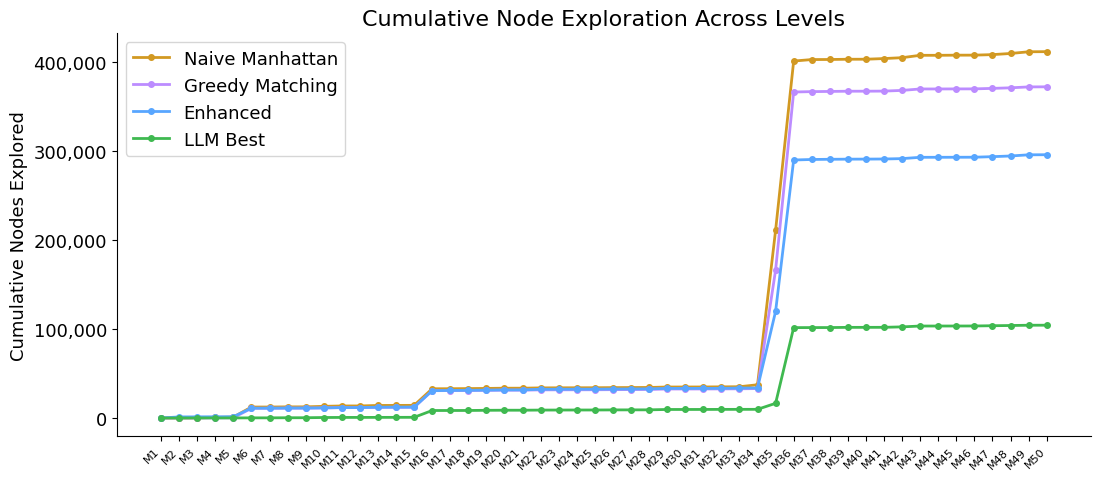

In [71]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.8, FIG_H))

for nodes_list, label, color in [
    (naive_nodes,    'Naive Manhattan', COLORS['naive_manhattan']),
    (greedy_nodes,   'Greedy Matching', COLORS['greedy_matching']),
    (enhanced_nodes, 'Enhanced',        COLORS['enhanced']),
    (llm_nodes,      'LLM Best',        COLORS['llm_best']),
]:
    cumulative = np.cumsum(nodes_list)
    ax.plot(range(len(levels)), cumulative, '-o', label=label, color=color,
            linewidth=2, markersize=4)

ax.set_xticks(range(len(levels)))
ax.set_xticklabels([l.replace('Microban ', 'M') for l in levels],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Cumulative Nodes Explored')
ax.set_title('Cumulative Node Exploration Across Levels')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend(loc='upper left')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save(fig, 'cumulative_nodes')
plt.show()

## 7. LLM Iteration Improvement Waterfall

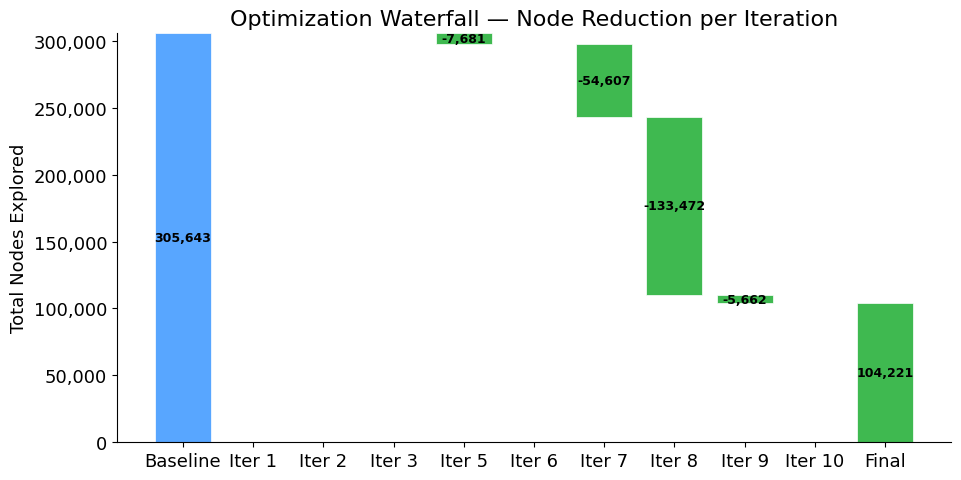

In [72]:
fig, ax = plt.subplots(figsize=(FIG_W * 0.7, FIG_H))

prev_nodes = sum(r['nodes'] for r in iterations[0]['results'])
labels_wf = ['Baseline']
deltas    = [prev_nodes]
colors_wf = [COLORS['baseline']]
bottoms   = [0]

running = prev_nodes
for it in iterations[1:]:
    cur_nodes = sum(r['nodes'] for r in it['results'])
    delta = cur_nodes - prev_nodes if it['accepted'] else 0
    labels_wf.append(f"Iter {it['iteration']}")
    if it['accepted']:
        deltas.append(delta)
        colors_wf.append(COLORS['accepted'] if delta < 0 else COLORS['rejected'])
        bottoms.append(running + delta if delta < 0 else running)
        running += delta
        prev_nodes = cur_nodes
    else:
        deltas.append(0)
        colors_wf.append('#555')
        bottoms.append(running)

# Final bar
labels_wf.append('Final')
deltas.append(running)
colors_wf.append(COLORS['llm_best'])
bottoms.append(0)

ax.bar(labels_wf, [abs(d) for d in deltas], bottom=bottoms,
       color=colors_wf, edgecolor='white', linewidth=0.5)

for i, (lbl, d) in enumerate(zip(labels_wf, deltas)):
    if d != 0:
        y = bottoms[i] + abs(d) / 2
        txt = f'{d:+,}' if i > 0 and i < len(labels_wf)-1 else f'{d:,}'
        ax.text(i, y, txt, ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_ylabel('Total Nodes Explored')
ax.set_title('Optimization Waterfall — Node Reduction per Iteration')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
save(fig, 'waterfall')
plt.show()

## 8. Best LLM Heuristic Source Code

In [73]:
from IPython.display import display, Markdown

source = best_info.get('source', 'N/A')
display(Markdown(f'```python\n{source}\n```'))

```python
from __future__ import annotations
from collections import deque
from functools import lru_cache
from typing import Tuple, FrozenSet

# reuse the direction list from the main solver
DIRECTIONS = [(0, -1), (1, 0), (0, 1), (-1, 0)]  # up, right, down, left


@lru_cache(maxsize=None)
def _push_distance_maps(
    walls: FrozenSet["Pos"], goals: Tuple["Pos", ...]
) -> Tuple[FrozenSet[Tuple["Pos", int]], ...]:
    """
    For each goal, return a frozenset of (Pos, distance) pairs where distance is
    the minimum number of pushes needed to move a box from that Pos to the goal,
    ignoring other boxes (only walls block). Cached for speed.
    """
    maps: list[FrozenSet[Tuple[Pos, int]]] = []
    for g in goals:
        dist: dict[Pos, int] = {}
        q: deque[Tuple[Pos, int]] = deque([(g, 0)])
        visited: set[Pos] = set()
        while q:
            p, d = q.popleft()
            if p in visited:
                continue
            visited.add(p)
            dist[p] = d
            for dx, dy in DIRECTIONS:
                # reverse a push: previous box location and player standing cell
                prev = Pos(p.x - dx, p.y - dy)
                player = Pos(p.x - 2 * dx, p.y - 2 * dy)
                if prev in walls or player in walls:
                    continue
                if prev not in visited:
                    q.append((prev, d + 1))
        maps.append(frozenset(dist.items()))
    return tuple(maps)


def heuristic(board: "Board", boxes: Tuple["Pos", ...]) -> int:
    """
    Admissible heuristic combining:
      1. Corner deadlock detection (large penalty for dead states).
      2. Optimal push‑distance assignment (pre‑computed per‑goal maps + DP).
      3. Simple line‑conflict penalty: each unordered pair of boxes that lie
         on the same row/column with no goal between them adds 1/2 extra push
         (rounded down) to the lower bound.
    """
    # ---- 1. Corner deadlock (same as earlier heuristic) -----------------
    goal_set = frozenset(board.goals)
    walls = board.walls
    for bx in boxes:
        if bx in goal_set:
            continue
        up = Pos(bx.x, bx.y - 1) in walls
        down = Pos(bx.x, bx.y + 1) in walls
        left = Pos(bx.x - 1, bx.y) in walls
        right = Pos(bx.x + 1, bx.y) in walls
        if (up and left) or (up and right) or (down and left) or (down and right):
            return 10_000   # dead position – large admissible penalty

    # ---- 2. Push‑distance based optimal assignment -----------------------
    maps_frozen = _push_distance_maps(board.walls, board.goals)
    maps = [dict(m) for m in maps_frozen]        # list of dict Pos->dist

    n = len(boxes)
    m = len(board.goals)                         # usually n == m
    INF = 10 ** 9

    # distance matrix (push distance, ignoring other boxes)
    dist = [[INF] * m for _ in range(n)]
    for i, bx in enumerate(boxes):
        for j in range(m):
            d = maps[j].get(bx, INF)
            dist[i][j] = d

    # any box that cannot reach any goal -> deadlock (large penalty)
    for i in range(n):
        if all(dist[i][j] == INF for j in range(m)):
            return 10_000

    @lru_cache(maxsize=None)
    def dp(i: int, mask: int) -> int:
        """minimum total push cost for boxes[i:] given used goals in mask."""
        if i == n:
            return 0
        best = INF
        for j in range(m):
            if mask & (1 << j):
                continue
            d = dist[i][j]
            if d == INF:
                continue
            cand = d + dp(i + 1, mask | (1 << j))
            if cand < best:
                best = cand
        return best

    base_cost = dp(0, 0)

    # ---- 3. Simple line‑conflict penalty ---------------------------------
    # count unordered box pairs that share a row or column with no goal between them
    conflict = 0
    # pre‑compute goal positions per row/col for fast lookup
    goals_by_row = {}
    goals_by_col = {}
    for g in board.goals:
        goals_by_row.setdefault(g.y, []).append(g.x)
        goals_by_col.setdefault(g.x, []).append(g.y)

    for i in range(n):
        bi = boxes[i]
        if bi in goal_set:
            continue
        for j in range(i + 1, n):
            bj = boxes[j]
            if bj in goal_set:
                continue
            # same row
            if bi.y == bj.y:
                minx, maxx = sorted((bi.x, bj.x))
                # any goal strictly between them?
                has_between = any(
                    minx < gx < maxx for gx in goals_by_row.get(bi.y, [])
                )
                if not has_between:
                    conflict += 1
            # same column
            if bi.x == bj.x:
                miny, maxy = sorted((bi.y, bj.y))
                has_between = any(
                    miny < gy < maxy for gy in goals_by_col.get(bi.x, [])
                )
                if not has_between:
                    conflict += 1

    # each conflict pair needs at least one extra push; divide by 2 to stay safe
    conflict_penalty = conflict // 2

    return base_cost + conflict_penalty
```

---

### Export Settings

Set `SAVE_FIGS = True` in the first cell and re-run all to save PNGs to `figures/`.

To customize colors, sizes, or chart types, edit the `COLORS`, `FIG_W/FIG_H`, and `FONT_SIZE` variables at the top.

In [76]:
# python3 heuristic_optimizer.py --random-select --ratio 0.4 --iters 10

# Load a saved heuristic for testing on any level
from heuristic_optimizer import load_heuristic, benchmark
from sokoban_solver import load_levels

fn = load_heuristic("best")
levels = load_levels("grids/Microban.txt")
levels = levels[:50]  # test on first 50 levels
results = benchmark(fn, levels)

In [77]:
sum(res['nodes'] for res in results)

129221

---

## 9. Comparison: First-20 Training vs 50-Select-20 Training

Does training on a fixed small set outperform random-subset training on a larger pool?
- **First-20**: optimizer trained on Microban 1–20 only
- **50-Select-20**: optimizer trained on random 20 of 50 levels each iteration, tested on all 50

In [78]:
# ── Load both result sets ──────────────────────────────────────────
with open('optimization_results_20.json') as f:
    data_20 = json.load(f)
with open('optimization_results_50_select_20.json') as f:
    data_50s = json.load(f)

levels_20  = data_20['levels']
levels_50s = data_50s['levels']
common     = [l for l in levels_20 if l in levels_50s]  # first 20

# Best LLM nodes per level
best_20_iter  = [it for it in data_20['iterations'] if it['accepted']][-1]
best_50s_iter = [it for it in data_50s['iterations'] if it['accepted']][-1]

nodes_20  = {r['level']: r['nodes'] for r in best_20_iter['results']}
nodes_50s = {r['level']: r['nodes'] for r in best_50s_iter['results']}

# Enhanced baseline on common levels (from the 50-select-20 baselines, same levels)
enh_50s = {r['level']: r['nodes'] for r in data_50s['baselines']['enhanced']['results']}

print(f"First-20 best total (20 levels): {sum(nodes_20[l] for l in levels_20):,}")
print(f"50-Select-20 best total (50 levels): {sum(nodes_50s[l] for l in levels_50s):,}")
print(f"Comparison on common {len(common)} levels:")
print(f"  First-20:     {sum(nodes_20[l] for l in common):,}")
print(f"  50-Select-20: {sum(nodes_50s[l] for l in common):,}")
print(f"  Enhanced:     {sum(enh_50s[l] for l in common):,}")

First-20 best total (20 levels): 8,088
50-Select-20 best total (50 levels): 104,221
Comparison on common 20 levels:
  First-20:     8,088
  50-Select-20: 8,757
  Enhanced:     31,557


### 9a. Per-Level Grouped Bar — Common 20 Levels

Side-by-side comparison of Enhanced baseline, First-20 LLM, and 50-Select-20 LLM on the shared levels.

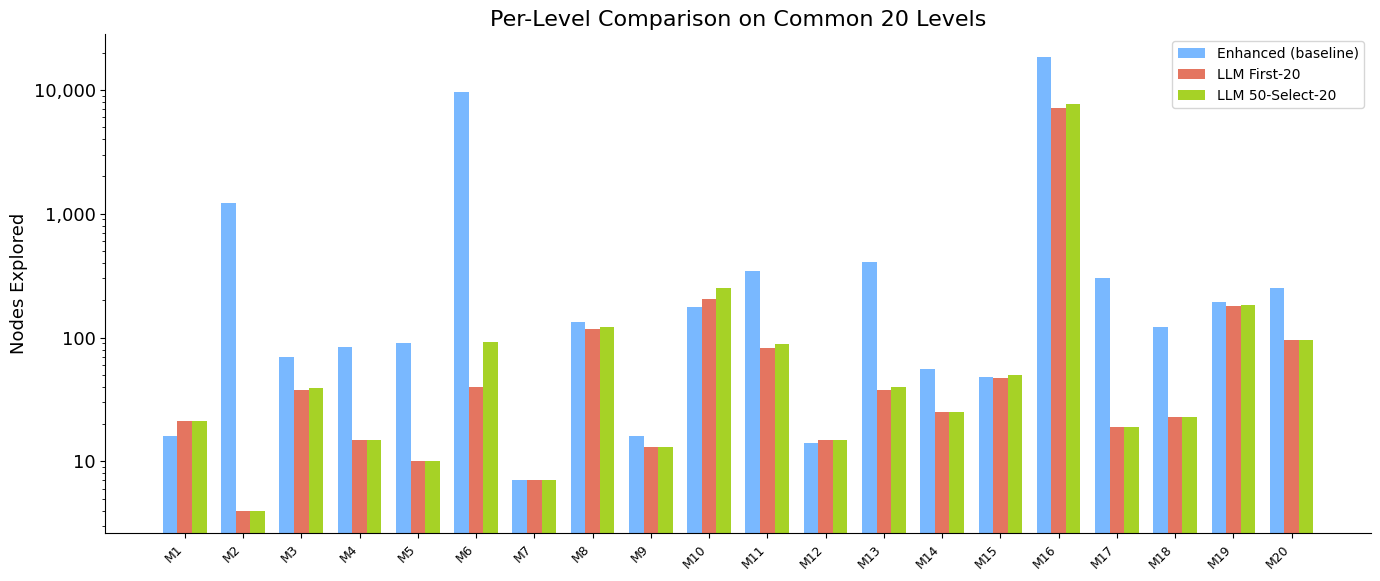

In [79]:
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H + 1))

x = np.arange(len(common))
w = 0.25

enh_vals  = [enh_50s[l] for l in common]
v20       = [nodes_20[l] for l in common]
v50s      = [nodes_50s[l] for l in common]

ax.bar(x - w, enh_vals, w, label='Enhanced (baseline)', color=COLORS['enhanced'], alpha=0.8)
ax.bar(x,     v20,      w, label='LLM First-20',        color='#e05d44',          alpha=0.85)
ax.bar(x + w, v50s,     w, label='LLM 50-Select-20',    color='#97ca00',          alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([l.replace('Microban ', 'M') for l in common],
                    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Nodes Explored')
ax.set_title('Per-Level Comparison on Common 20 Levels')
ax.set_yscale('log')
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
save(fig, 'compare_20_vs_50s_bar')
plt.show()

### 9b. Node Difference — First-20 vs 50-Select-20

Per-level node difference (positive = First-20 is better). Highlights which levels each strategy wins.

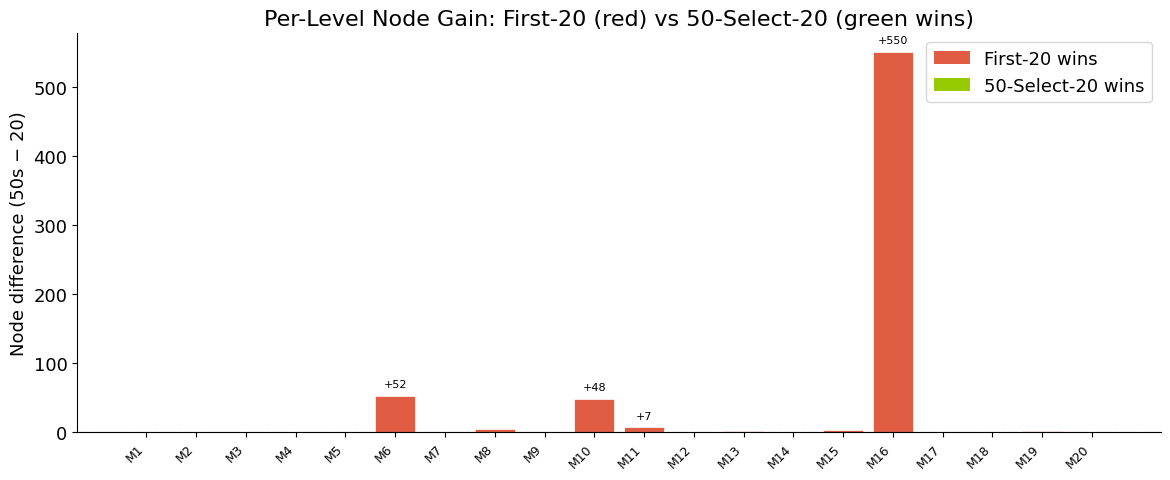

In [80]:
diff = [nodes_50s[l] - nodes_20[l] for l in common]  # positive ⇒ First-20 wins
colors_diff = ['#e05d44' if d > 0 else '#97ca00' for d in diff]

fig, ax = plt.subplots(figsize=(FIG_W * 0.85, FIG_H))

ax.bar(range(len(common)), diff, color=colors_diff, edgecolor='white', linewidth=0.5)
ax.axhline(0, color='grey', linewidth=0.8, linestyle='--')

# Labels
for i, (d, lvl) in enumerate(zip(diff, common)):
    if abs(d) > 5:
        ax.text(i, d + (10 if d > 0 else -10), f'{d:+,}',
                ha='center', va='bottom' if d > 0 else 'top', fontsize=8)

ax.set_xticks(range(len(common)))
ax.set_xticklabels([l.replace('Microban ', 'M') for l in common],
                    rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Node difference (50s − 20)')
ax.set_title('Per-Level Node Gain: First-20 (red) vs 50-Select-20 (green wins)')
ax.spines[['top', 'right']].set_visible(False)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='#e05d44', label='First-20 wins'),
    Patch(facecolor='#97ca00', label='50-Select-20 wins'),
], loc='upper right')

plt.tight_layout()
save(fig, 'compare_diff')
plt.show()

### 9c. Summary Comparison Table

In [81]:
enh_common  = sum(enh_50s[l] for l in common)
n20_common  = sum(nodes_20[l] for l in common)
n50s_common = sum(nodes_50s[l] for l in common)

cmp_rows = [
    {'Strategy': 'Enhanced (baseline)',
     'Train Set': '—',
     'Nodes (common 20)': enh_common,
     'vs Baseline (%)': '—',
     'Accepted Iters': '—'},
    {'Strategy': 'LLM First-20',
     'Train Set': 'M1–M20 (fixed)',
     'Nodes (common 20)': n20_common,
     'vs Baseline (%)': f"{(enh_common - n20_common) / enh_common * 100:+.1f}%",
     'Accepted Iters': sum(1 for it in data_20['iterations'][1:] if it['accepted'])},
    {'Strategy': 'LLM 50-Select-20',
     'Train Set': 'Random 20/50',
     'Nodes (common 20)': n50s_common,
     'vs Baseline (%)': f"{(enh_common - n50s_common) / enh_common * 100:+.1f}%",
     'Accepted Iters': sum(1 for it in data_50s['iterations'][1:] if it['accepted'])},
]

cmp_df = pd.DataFrame(cmp_rows)

# Also add full-50 stats for the 50-select-20 strategy
enh_full  = sum(r['nodes'] for r in data_50s['baselines']['enhanced']['results'])
n50s_full = sum(nodes_50s[l] for l in levels_50s)
print(f"Full 50 levels — Enhanced: {enh_full:,}  |  50-Select-20 LLM: {n50s_full:,}  "
      f"({(enh_full - n50s_full) / enh_full * 100:+.1f}%)")

wins_20  = sum(1 for l in common if nodes_20[l] < nodes_50s[l])
wins_50s = sum(1 for l in common if nodes_50s[l] < nodes_20[l])
ties     = sum(1 for l in common if nodes_20[l] == nodes_50s[l])
print(f"Head-to-head on {len(common)} levels: First-20 wins {wins_20}, 50-Select-20 wins {wins_50s}, ties {ties}")

cmp_df.style.format({'Nodes (common 20)': '{:,}'})

Full 50 levels — Enhanced: 295,643  |  50-Select-20 LLM: 104,221  (+64.7%)
Head-to-head on 20 levels: First-20 wins 9, 50-Select-20 wins 0, ties 11


,Strategy,Train Set,Nodes (common 20),vs Baseline (%),Accepted Iters
0,Enhanced (baseline),—,"31,557",—,—
1,LLM First-20,M1–M20 (fixed),"8,088",+74.4%,4
2,LLM 50-Select-20,Random 20/50,"8,757",+72.3%,4


### 9d. Optimization Convergence — Both Strategies

Total nodes (on their respective test sets) across accepted iterations.

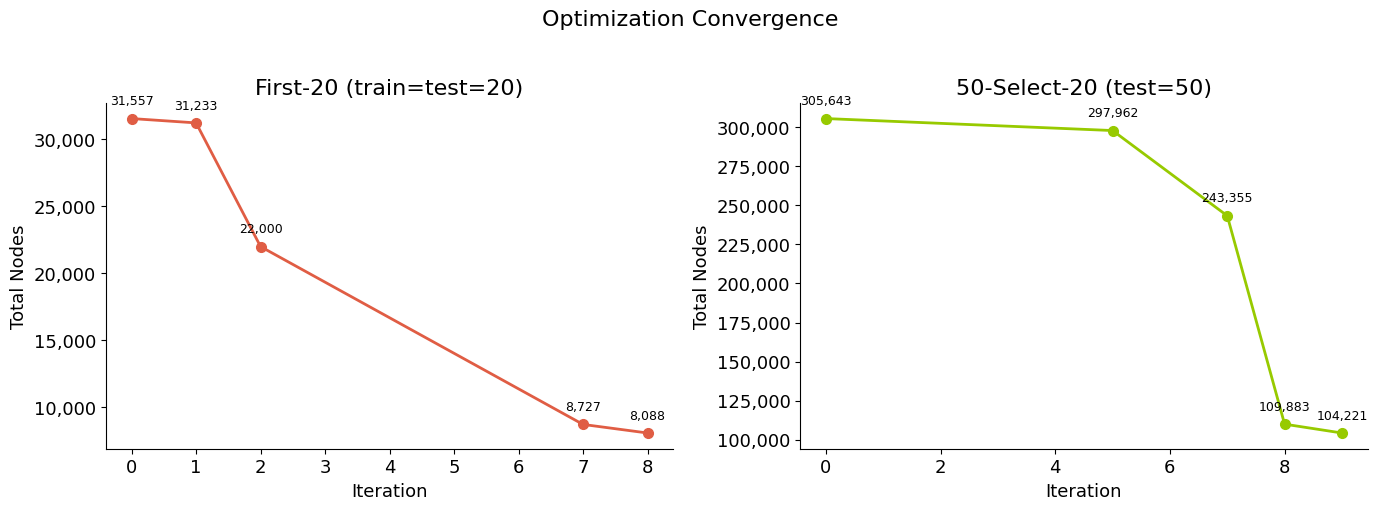

In [82]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(FIG_W, FIG_H), sharey=False)

for ax, dset, title, color in [
    (ax1, data_20,  'First-20 (train=test=20)',  '#e05d44'),
    (ax2, data_50s, '50-Select-20 (test=50)',    '#97ca00'),
]:
    accepted = [it for it in dset['iterations'] if it['accepted']]
    xs = [it['iteration'] for it in accepted]
    ys = [it['summary']['total_nodes'] for it in accepted]
    ax.plot(xs, ys, 'o-', color=color, linewidth=2, markersize=7)
    for xi, yi in zip(xs, ys):
        ax.annotate(f'{yi:,}', (xi, yi), textcoords='offset points',
                    xytext=(0, 10), ha='center', fontsize=9)
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Total Nodes')
    ax.set_title(title)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle('Optimization Convergence', fontsize=TITLE_SIZE, y=1.02)
plt.tight_layout()
save(fig, 'compare_convergence')
plt.show()